# Red Neuronal Convolucional (CNN) - Clasificador de Animales
### Clases: Ranas, Pájaros, Ballenas, Changos, Arañas
### Imágenes: 28x28 píxeles, RGB (Color), 10,000 por clase

# 1. Importar Librerías

In [1]:
import numpy as np
import os
import re
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.12.0


# 2. Cargar Imágenes del Dataset

**Estructura esperada de carpetas:**
```
Dataset_Final/
├── ranas/       (10,000 imágenes)
├── pajaros/     (10,000 imágenes)
├── ballenas/    (10,000 imágenes)
├── changos/     (10,000 imágenes)
└── arañas/      (10,000 imágenes)
```

In [2]:
# Ruta a la carpeta principal del dataset
dirname = os.path.join(os.getcwd(), 'dataset3')
imgpath = dirname + os.sep

images = []
labels = []

# Nombres de las clases (deben coincidir EXACTAMENTE con los nombres de las carpetas)
clases_nombres = ['ranas', 'pajaros', 'ballenas', 'changos', 'aranas']

print("Leyendo imágenes de:", imgpath)
print("-" * 50)

dircount = []  # guardará cuántas imágenes tiene cada clase

for idx, clase in enumerate(clases_nombres):
    folder = os.path.join(imgpath, clase)
    
    if not os.path.exists(folder):
        print(f"⚠️  ALERTA: No se encontró la carpeta '{clase}' en {folder}")
        continue
    
    contador = 0
    for filename in os.listdir(folder):
        if re.search(r"\.(jpg|jpeg|png|bmp)$", filename, re.IGNORECASE):
            filepath = os.path.join(folder, filename)
            image = cv2.imread(filepath, cv2.IMREAD_COLOR)
            if image is not None:
                # Nos aseguramos que todas sean 35x35
                image = cv2.resize(image, (28, 28))
                images.append(image)
                labels.append(idx)
                contador += 1
    
    dircount.append(contador)
    print(f"Clase {idx} - {clase}: {contador} imágenes cargadas")

print("-" * 50)
print(f'✅ Total de imágenes cargadas: {len(images)}')

Leyendo imágenes de: c:\Users\jo296\Documents\IA\Proyecto2\dataset3\
--------------------------------------------------
Clase 0 - ranas: 14511 imágenes cargadas
Clase 1 - pajaros: 14495 imágenes cargadas
Clase 2 - ballenas: 14376 imágenes cargadas
Clase 3 - changos: 14448 imágenes cargadas
Clase 4 - aranas: 14372 imágenes cargadas
--------------------------------------------------
✅ Total de imágenes cargadas: 72202


# 3. Verificar Equilibrio del Dataset

=== EQUILIBRIO DEL DATASET ===
----------------------------------------
Clase 0 | ranas      |  14511 imágenes | █████████████████████████████
Clase 1 | pajaros    |  14495 imágenes | ████████████████████████████
Clase 2 | ballenas   |  14376 imágenes | ████████████████████████████
Clase 3 | changos    |  14448 imágenes | ████████████████████████████
Clase 4 | aranas     |  14372 imágenes | ████████████████████████████
----------------------------------------
Total: 72202 imágenes
⚠️  Dataset DESBALANCEADO (mín: 14372, máx: 14511)


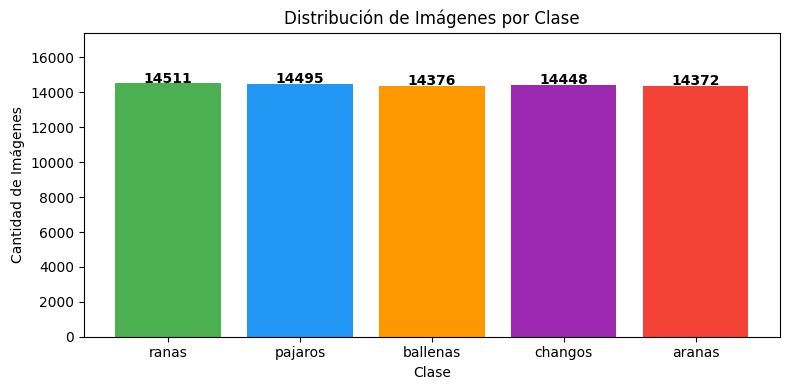

In [3]:
print("=== EQUILIBRIO DEL DATASET ===")
print("-" * 40)
for i, (clase, cantidad) in enumerate(zip(clases_nombres, dircount)):
    barra = '█' * (cantidad // 500)
    print(f"Clase {i} | {clase:<10} | {cantidad:>6} imágenes | {barra}")

print("-" * 40)
total = sum(dircount)
print(f"Total: {total} imágenes")

# Verificar si está balanceado
min_clase = min(dircount)
max_clase = max(dircount)
if max_clase - min_clase <= 100:
    print("✅ Dataset BALANCEADO (diferencia <= 100 imágenes entre clases)")
else:
    print(f"⚠️  Dataset DESBALANCEADO (mín: {min_clase}, máx: {max_clase})")

# Gráfica de equilibrio
plt.figure(figsize=(8, 4))
plt.bar(clases_nombres, dircount, color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336'])
plt.title('Distribución de Imágenes por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Imágenes')
plt.ylim(0, max(dircount) * 1.2)
for i, v in enumerate(dircount):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Convertir a Matrices Numpy

In [4]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8)

# Reshape: (N, 28, 28) -> (N, 28, 28, 1)  [1 = escala de grises]
X = X.reshape(X.shape[0], 28, 28, 3)

classes = np.unique(y)
nClasses = len(classes)

print(f'Forma de X (imágenes): {X.shape}')
print(f'Forma de y (etiquetas): {y.shape}')
print(f'Número de clases: {nClasses}')
print(f'Clases: {list(zip(classes, clases_nombres))}')

Forma de X (imágenes): (72202, 28, 28, 3)
Forma de y (etiquetas): (72202,)
Número de clases: 5
Clases: [(np.int64(0), 'ranas'), (np.int64(1), 'pajaros'), (np.int64(2), 'ballenas'), (np.int64(3), 'changos'), (np.int64(4), 'aranas')]


# 5. Dividir en Sets de Entrenamiento y Prueba

In [5]:
# 80% entrenamiento, 20% prueba
train_X, test_X, train_Y, test_Y = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Set de Entrenamiento: {train_X.shape}  |  Etiquetas: {train_Y.shape}')
print(f'Set de Prueba:        {test_X.shape}   |  Etiquetas: {test_Y.shape}')

Set de Entrenamiento: (57761, 28, 28, 3)  |  Etiquetas: (57761,)
Set de Prueba:        (14441, 28, 28, 3)   |  Etiquetas: (14441,)


# 6. Visualizar Ejemplos del Dataset

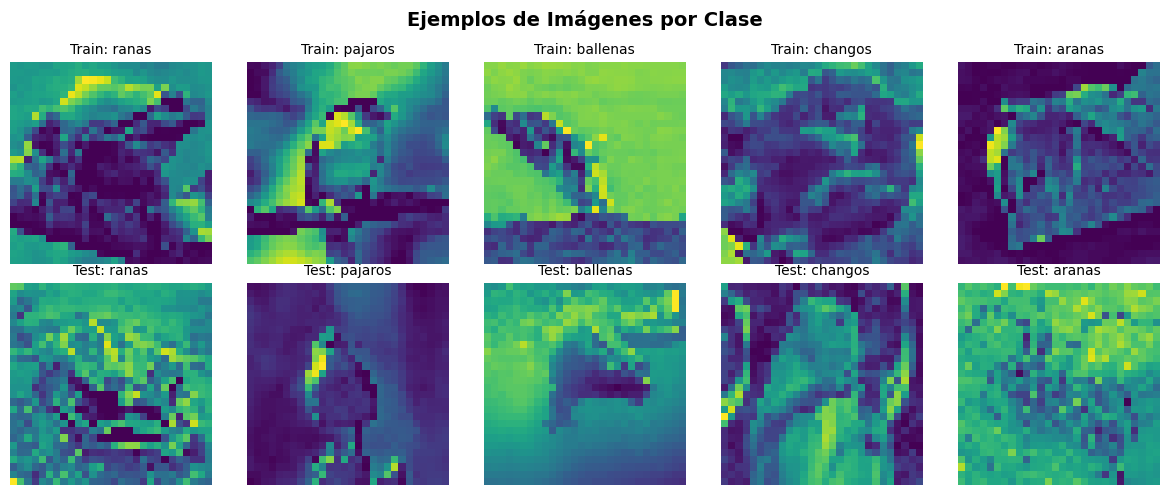

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Ejemplos de Imágenes por Clase', fontsize=14, fontweight='bold')

for clase_idx in range(nClasses):
    idx = np.where(train_Y == clase_idx)[0][0]
    
    axes[0, clase_idx].imshow(train_X[idx, :, :, 0])
    axes[0, clase_idx].set_title(f'Train: {clases_nombres[clase_idx]}', fontsize=10)
    axes[0, clase_idx].axis('off')
    
    idx2 = np.where(test_Y == clase_idx)[0][0]
    axes[1, clase_idx].imshow(test_X[idx2, :, :, 0])
    axes[1, clase_idx].set_title(f'Test: {clases_nombres[clase_idx]}', fontsize=10)
    axes[1, clase_idx].axis('off')

plt.tight_layout()
plt.show()

# 7. Preprocesar las Imágenes (Normalización)

In [7]:
# Convertir a float y normalizar entre 0 y 1
train_X = train_X.astype('float32') / 255.0
test_X  = test_X.astype('float32')  / 255.0

print(f'Rango de valores - Mín: {train_X.min():.2f}, Máx: {train_X.max():.2f}')
print('✅ Imágenes normalizadas correctamente')

Rango de valores - Mín: 0.00, Máx: 1.00
✅ Imágenes normalizadas correctamente


# 8. One-Hot Encoding de Etiquetas

In [8]:
train_Y_one_hot = to_categorical(train_Y, num_classes=nClasses)
test_Y_one_hot  = to_categorical(test_Y,  num_classes=nClasses)

print('Etiqueta original (train_Y[0]):', train_Y[0], '->', clases_nombres[train_Y[0]])
print('One-hot encoding:', train_Y_one_hot[0])

Etiqueta original (train_Y[0]): 4 -> aranas
One-hot encoding: [0. 0. 0. 0. 1.]


# 9. Crear Set de Validación

In [9]:
# Dividir el set de entrenamiento en entrenamiento (80%) y validación (20%)
train_X, valid_X, train_label, valid_label = train_test_split(
    train_X, train_Y_one_hot, test_size=0.2, random_state=48
)

print(f'Entrenamiento: {train_X.shape}  |  Labels: {train_label.shape}')
print(f'Validación:    {valid_X.shape}   |  Labels: {valid_label.shape}')
print(f'Prueba:        {test_X.shape}    |  Labels: {test_Y_one_hot.shape}')

Entrenamiento: (46208, 28, 28, 3)  |  Labels: (46208, 5)
Validación:    (11553, 28, 28, 3)   |  Labels: (11553, 5)
Prueba:        (14441, 28, 28, 3)    |  Labels: (14441, 5)


# 10. Crear el Modelo CNN

**Arquitectura:** 2 capas convolucionales + capas densas para clasificación

In [10]:
# Parámetros de entrenamiento
INIT_LR    = 1e-3   # Learning rate inicial
epochs     = 40     # 40 épocas para mejor precisión
batch_size = 32     # Imágenes por lote

In [11]:
# =============================================
#   ARQUITECTURA CNN - 2 CAPAS CONVOLUCIONALES
# =============================================
sport_model = Sequential(name='CNN_Animales')

# --- CAPA CONVOLUCIONAL 1 ---
sport_model.add(Conv2D(32, kernel_size=(3, 3), activation='linear',
                       padding='same', input_shape=(28, 28, 3)))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.3))

# --- CAPA CONVOLUCIONAL 2 ---
sport_model.add(Conv2D(64, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.3))

# --- CAPAS DENSAS (Clasificación final) ---
sport_model.add(Flatten())
sport_model.add(Dense(128, activation='linear'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Dropout(0.5))
sport_model.add(Dense(nClasses, activation='softmax'))

sport_model.summary()

c:\Users\jo296\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\jo296\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "CNN_Animales"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,573 (1.61 MB)

 Trainable params: 421,573 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

# 11. Compilar el Modelo

In [12]:
sport_model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),
    metrics=['accuracy']
)
print('✅ Modelo compilado correctamente')

✅ Modelo compilado correctamente


# 12. Entrenar el Modelo

> ⏳ Este paso puede tardar varios minutos dependiendo de tu CPU/GPU.

In [13]:
sport_train = sport_model.fit(
    train_X, train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(valid_X, valid_label)
)

Epoch 1/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8868 - loss: 0.3095 - val_accuracy: 0.9839 - val_loss: 0.0554
Epoch 2/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9813 - loss: 0.0619 - val_accuracy: 0.9976 - val_loss: 0.0111
Epoch 3/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9883 - loss: 0.0372 - val_accuracy: 0.9967 - val_loss: 0.0122
Epoch 4/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9910 - loss: 0.0280 - val_accuracy: 0.9994 - val_loss: 0.0022
Epoch 5/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9920 - loss: 0.0255 - val_accuracy: 0.9996 - val_loss: 0.0026
Epoch 6/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9928 - loss: 0.0244 - val_accuracy: 0.9992 - val_loss: 0.0045
Epoch 7/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9931 - loss: 0.0214 - val_accuracy: 0.9993 - val_loss: 0.0029
Epoch 8/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9941 -

# 13. Guardar el Modelo Entrenado

In [14]:
sport_model.save("modelo_animales_final.h5")
print("✅ Modelo guardado como: modelo_animales_final.h5")

✅ Modelo guardado como: modelo_animales_final.h5


# 14. Evaluar el Modelo

In [15]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)
print(f'\nPérdida (Loss):   {test_eval[0]:.4f}')
print(f'Precisión (Acc):  {test_eval[1]*100:.2f}%')

452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9993 - loss: 0.0045

Pérdida (Loss):   0.0045
Precisión (Acc):  99.93%


# 15. Gráficas de Entrenamiento

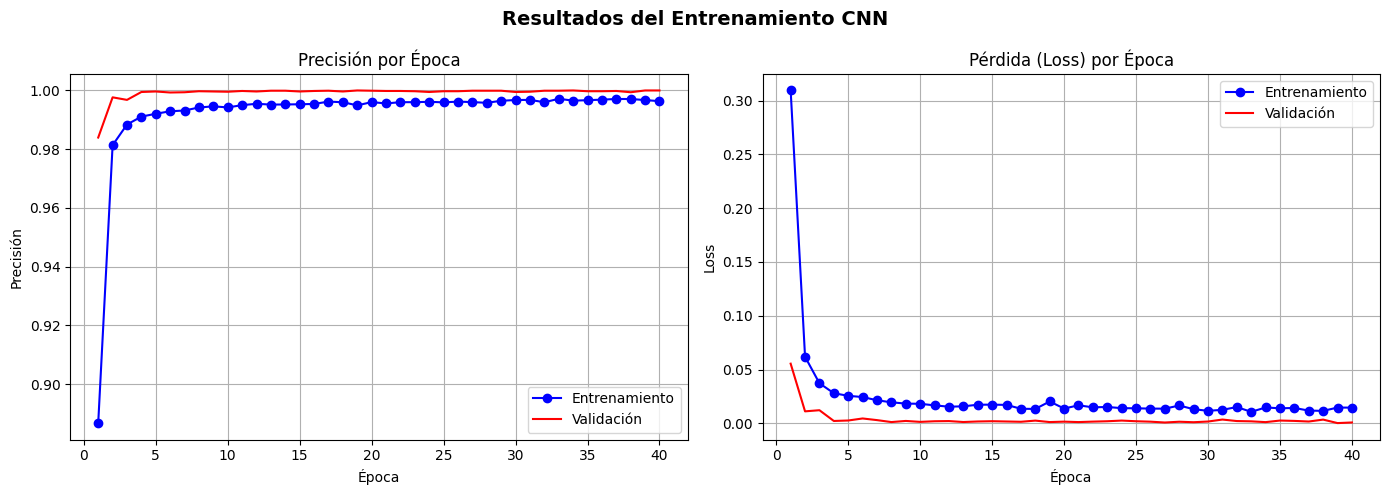

In [16]:
accuracy     = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss         = sport_train.history['loss']
val_loss     = sport_train.history['val_loss']
epocas_rango = range(1, len(accuracy) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epocas_rango, accuracy,     'bo-', label='Entrenamiento')
ax1.plot(epocas_rango, val_accuracy, 'r-',  label='Validación')
ax1.set_title('Precisión por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True)

ax2.plot(epocas_rango, loss,     'bo-', label='Entrenamiento')
ax2.plot(epocas_rango, val_loss, 'r-',  label='Validación')
ax2.set_title('Pérdida (Loss) por Época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Resultados del Entrenamiento CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 16. Reporte de Clasificación

In [17]:
predicted_probs   = sport_model.predict(test_X)
predicted_classes = np.argmax(predicted_probs, axis=1)

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(test_Y, predicted_classes, target_names=clases_nombres))

452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

       ranas       1.00      1.00      1.00      2902
     pajaros       1.00      1.00      1.00      2899
    ballenas       1.00      1.00      1.00      2875
     changos       1.00      1.00      1.00      2890
      aranas       1.00      1.00      1.00      2875

    accuracy                           1.00     14441
   macro avg       1.00      1.00      1.00     14441
weighted avg       1.00      1.00      1.00     14441



# 17. Ver Aciertos y Errores

Correctas:   14431
Incorrectas: 10


C:\Users\jo296\AppData\Local\Temp\ipykernel_34280\3493664789.py:14: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jo296\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


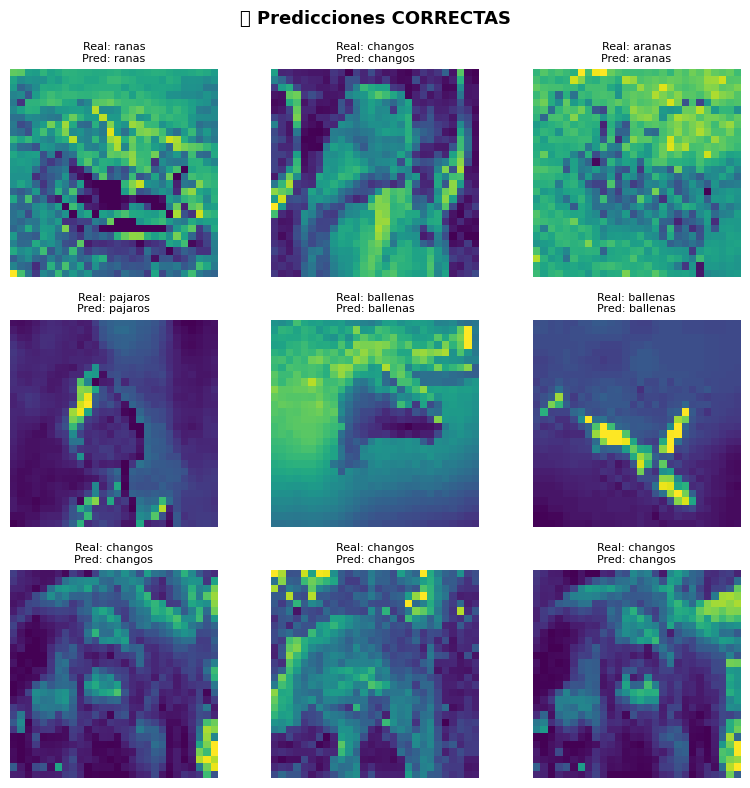

C:\Users\jo296\AppData\Local\Temp\ipykernel_34280\3493664789.py:26: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jo296\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


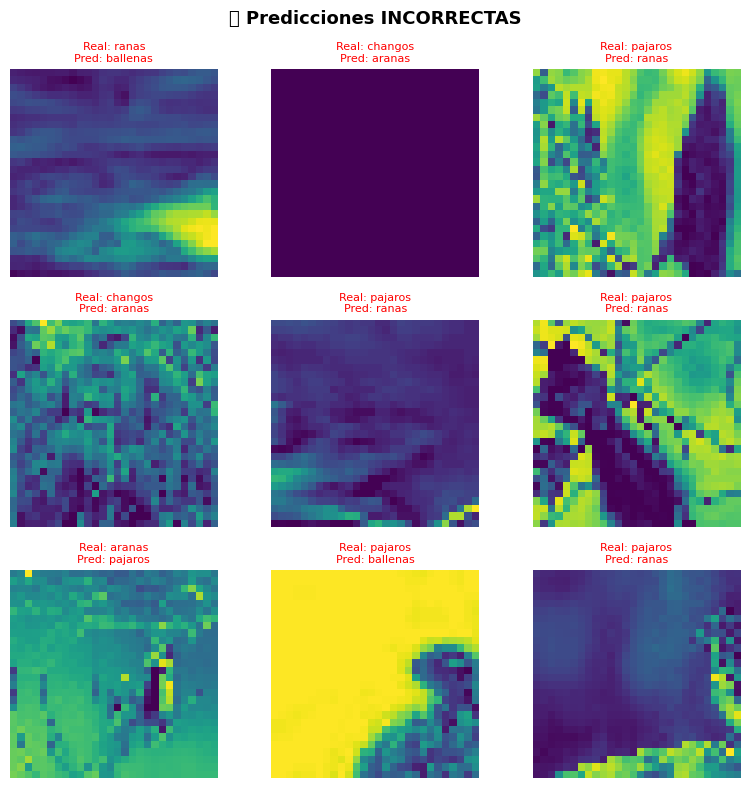

In [18]:
correct   = np.where(predicted_classes == test_Y)[0]
incorrect = np.where(predicted_classes != test_Y)[0]
print(f'Correctas:   {len(correct)}')
print(f'Incorrectas: {len(incorrect)}')

# Mostrar 9 aciertos
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('✅ Predicciones CORRECTAS', fontsize=13, fontweight='bold')
for i, idx in enumerate(correct[:9]):
    ax = axes[i // 3, i % 3]
    ax.imshow(test_X[idx, :, :, 0])
    ax.set_title(f'Real: {clases_nombres[test_Y[idx]]}\nPred: {clases_nombres[predicted_classes[idx]]}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Mostrar 9 errores
if len(incorrect) > 0:
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    fig.suptitle('❌ Predicciones INCORRECTAS', fontsize=13, fontweight='bold')
    for i, idx in enumerate(incorrect[:9]):
        ax = axes[i // 3, i % 3]
        ax.imshow(test_X[idx, :, :, 0])
        ax.set_title(f'Real: {clases_nombres[test_Y[idx]]}\nPred: {clases_nombres[predicted_classes[idx]]}', fontsize=8, color='red')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

---
# ════════════════════════════════════════
# 🔄 DESDE AQUÍ PUEDES EMPEZAR SIN REENTRENAR
# ════════════════════════════════════════
### Si reinicias el kernel, ejecuta solo las celdas 18 y 19

# 18. Cargar Modelo Guardado
### ▶️ Ejecuta esta celda PRIMERO si reinicias el kernel

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Cargamos el modelo ya entrenado
sport_model = load_model('modelo_animales_final.h5')

# Nombres de clases (siempre deben estar definidos)
clases_nombres = ['ranas', 'pajaros', 'ballenas', 'changos', 'aranas']

print('✅ Modelo cargado correctamente')
print('✅ Listo para identificar animales — ejecuta la celda 19')

✅ Modelo cargado correctamente
✅ Listo para identificar animales — ejecuta la celda 19


# 19. 🔍 Identificar una Imagen Nueva
### ▶️ Ejecuta esta celda cada vez que quieras identificar un animal
> Se abrirá una ventana para que **selecciones cualquier imagen de tu PC**

📂 5 imagen(es) seleccionada(s)


🔍 Procesando imagen 1: C:/Users/jo296/Documents/IA/Proyecto2/animales_prueba4/14edb4c7-1e8c-4918-b80e-7c1bb1fb8590.png


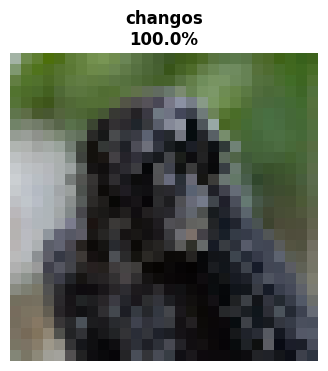

🐾 Resultado: CHANGOS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   : 100.0% █████████████████████████████
   aranas    :   0.0% 

🔍 Procesando imagen 2: C:/Users/jo296/Documents/IA/Proyecto2/animales_prueba4/56b1dad8-9476-42bc-bbe7-e7daf25ebbdb.png


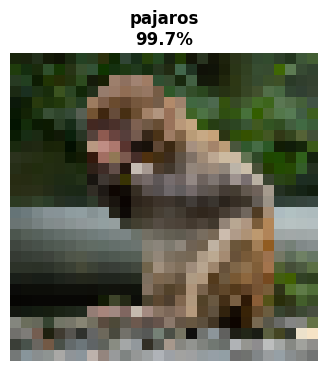

🐾 Resultado: PAJAROS (99.7%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :  99.7% █████████████████████████████
   ballenas  :   0.0% 
   changos   :   0.3% 
   aranas    :   0.0% 

🔍 Procesando imagen 3: C:/Users/jo296/Documents/IA/Proyecto2/animales_prueba4/62212999-bcb6-4d75-897c-37acf8a64e20.png


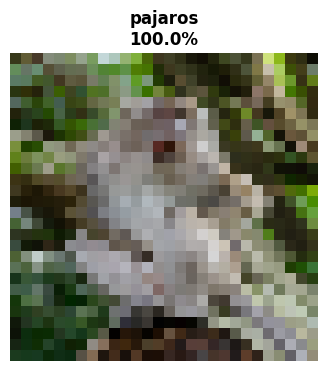

🐾 Resultado: PAJAROS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   : 100.0% █████████████████████████████
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

🔍 Procesando imagen 4: C:/Users/jo296/Documents/IA/Proyecto2/animales_prueba4/c8.jpg


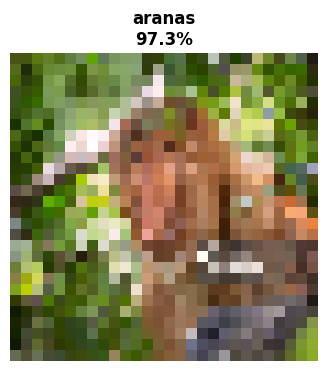

🐾 Resultado: ARANAS (97.3%)
   Probabilidades:
   ranas     :   0.1% 
   pajaros   :   2.5% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :  97.3% █████████████████████████████

🔍 Procesando imagen 5: C:/Users/jo296/Documents/IA/Proyecto2/animales_prueba4/c10.jpg


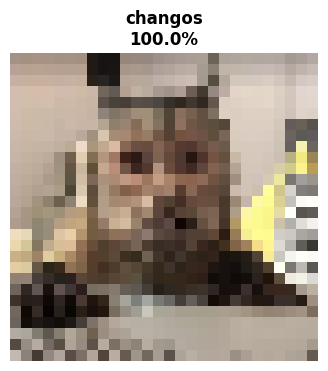

🐾 Resultado: CHANGOS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   : 100.0% █████████████████████████████
   aranas    :   0.0% 


In [11]:
# =============================================
#   PREDICCIÓN CON SELECTOR DE MÚLTIPLES IMÁGENES
# =============================================
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Abrir ventana para seleccionar múltiples imágenes
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

imagenes = filedialog.askopenfilenames(
    title="Selecciona una o varias imágenes",
    filetypes=[
        ("Imágenes", "*.jpg *.jpeg *.png *.bmp *.tiff"),
        ("Todos los archivos", "*.*")
    ]
)

root.destroy()

# Verificar si se seleccionaron imágenes
if not imagenes:
    print("⚠️ No seleccionaste ninguna imagen.")
else:
    print(f"📂 {len(imagenes)} imagen(es) seleccionada(s)\n")

    # Recorrer cada imagen
    for i, ruta in enumerate(imagenes):
        print(f"\n🔍 Procesando imagen {i+1}: {ruta}")

        img = cv2.imread(ruta, cv2.IMREAD_COLOR)

        if img is None:
            print("❌ No se pudo leer la imagen.")
            continue

        # Redimensionar
        img_resized = cv2.resize(img, (28, 28))

        # Preparar para el modelo
        img_array = img_resized.astype('float32') / 255.0
        img_array = img_array.reshape(1, 28, 28, 3)

        # Predecir
        prediccion = sport_model.predict(img_array, verbose=0)
        clase_idx  = np.argmax(prediccion)
        confianza  = prediccion[0][clase_idx] * 100

        # Mostrar imagen
        plt.figure(figsize=(4, 4))
        plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
        plt.title(
            f'{clases_nombres[clase_idx]}\n{confianza:.1f}%',
            fontsize=12,
            fontweight='bold'
        )
        plt.axis('off')
        plt.show()

        # Consola
        print(f'🐾 Resultado: {clases_nombres[clase_idx].upper()} ({confianza:.1f}%)')

        print('   Probabilidades:')
        for clase, prob in zip(clases_nombres, prediccion[0]):
            barra = '█' * int(prob * 30)
            print(f'   {clase:<10}: {prob*100:5.1f}% {barra}')